       h          avg(y)       avg error       x near 15       y(x near 15)           exact     local error
---------------------------------------------------------------------------------------------------------
    0.01      1.91082743      0.36859275     15.00000000         0.23143958      0.27237495      0.04093536
    0.05      1.01860215      1.25961398     15.00000000         0.11986884      0.27237495      0.15250610
    0.15      0.32050526      1.95583948     15.00000000         0.02092134      0.27237495      0.25145361
    0.20      0.20456815      2.06765094     15.00000000         0.00790326      0.27237495      0.26447169
    0.25      0.13633524      2.14028823     15.00000000         0.00266229      0.27237495      0.26971266
    0.50      0.01587302      2.26151967     15.00000000         0.00000000      0.27237495      0.27237495
    0.75      0.06022324      2.21803750     15.00000000         0.00157409      0.27237495      0.27080086
    1.00      1.39247046      

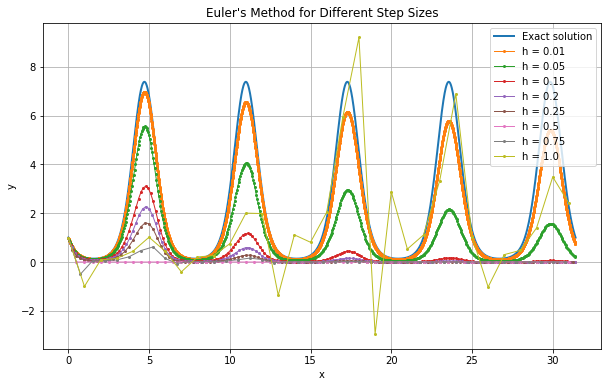

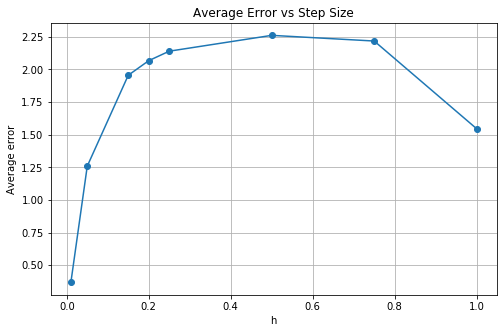

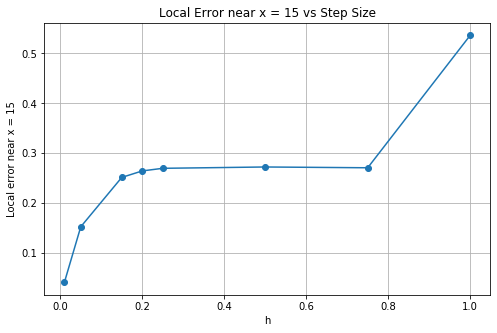

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Differential equation:
# dy/dx = -2y*cos(x),   y(0) = 1
# Exact solution:
# y(x) = exp(-2 sin(x))

def f(x, y):
    return -2 * y * np.cos(x)

def exact_solution(x):
    return np.exp(-2 * np.sin(x))

def euler_method(h, x0=0.0, x_end=10*np.pi, y0=1.0):
    n_steps = int(np.floor((x_end - x0) / h))
    x = x0 + h * np.arange(n_steps + 1)
    y = np.zeros(n_steps + 1)
    y[0] = y0

    for i in range(n_steps):
        y[i+1] = y[i] + h * f(x[i], y[i])

    return x, y

# Step sizes from the prompt
h_vals = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]

# Store results
results = []
avg_y_vals = []
avg_errors = []
local_errors = []

target_x = 15.0

for h in h_vals:
    x_num, y_num = euler_method(h)
    y_exact = exact_solution(x_num)

    # Average of y-values for this run
    avg_y = np.mean(y_num)

    # Average error over the whole run
    error = np.abs(y_num - y_exact)
    avg_error = np.mean(error)

    # Local error near x = 15
    idx_15 = np.argmin(np.abs(x_num - target_x))
    x_near_15 = x_num[idx_15]
    local_error = abs(y_num[idx_15] - exact_solution(x_near_15))

    results.append((h, x_num, y_num, y_exact, x_near_15))
    avg_y_vals.append(avg_y)
    avg_errors.append(avg_error)
    local_errors.append(local_error)

# Print comparison table
print(f"{'h':>8} {'avg(y)':>15} {'avg error':>15} {'x near 15':>15} {'y(x near 15)':>18} {'exact':>15} {'local error':>15}")
print("-" * 105)

for i, (h, x_num, y_num, y_exact, x_near_15) in enumerate(results):
    idx_15 = np.argmin(np.abs(x_num - target_x))
    print(f"{h:8.2f} {avg_y_vals[i]:15.8f} {avg_errors[i]:15.8f} {x_near_15:15.8f} {y_num[idx_15]:18.8f} {y_exact[idx_15]:15.8f} {local_errors[i]:15.8f}")

# -------------------------------
# Plot 1: Euler solutions for each h
# -------------------------------
plt.figure(figsize=(10, 6))

# Exact solution for reference
x_exact_plot = np.linspace(0, 10*np.pi, 2000)
plt.plot(x_exact_plot, exact_solution(x_exact_plot), label='Exact solution', linewidth=2)

for h, x_num, y_num, _, _ in results:
    plt.plot(x_num, y_num, marker='o', markersize=2, linewidth=1, label=f'h = {h}')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot 2: Average error vs h
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(h_vals, avg_errors, marker='o')
plt.xlabel('h')
plt.ylabel('Average error')
plt.title('Average Error vs Step Size')
plt.grid(True)
plt.show()

# -------------------------------
# Plot 3: Local error near x = 15 vs h
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(h_vals, local_errors, marker='o')
plt.xlabel('h')
plt.ylabel('Local error near x = 15')
plt.title('Local Error near x = 15 vs Step Size')
plt.grid(True)
plt.show()

### Analysis

### Plot 1

As we increase the step size the oscillations become less pronounced and eventually become a flat line.This indicates that large step sizes overlook the osciallatory features of the solution.

### Plot 2
As we increase the step size for the most part the average error goes up, but besides at in the region from 0.8 at 1.0. At first I thought this was a bug in my code, but on further investigation this an artifact of the function being oscillatory. Specifically how the sampling interacts with oscillatory structure of the solution, artifically lowering the error. We know this isn't just an artifact through plot #3.

### Plot 3
As we increase the step size the error at local error at x = 15 increases with bigger step sizes. This pattern highlights the error in a smaller region not allowing a correction from the shape of the function like in plot #2.

## Stability Analysis for \( y' = -2y\cos(x) \)

We compare this to the standard test equation:
\[
y' = \lambda y
\]

For our equation,
\[
y' = -2y\cos(x)
\]
we can think of it as:
\[
\lambda(x) = -2\cos(x)
\]

---

### Euler’s Method Update

Using Euler’s method:
\[
y_{n+1} = y_n + h(-2y_n\cos(x_n))
\]

Factor out \( y_n \):
\[
y_{n+1} = (1 - 2h\cos(x_n))y_n
\]

---

### Stability Condition

For stability, we require:
\[
|1 - 2h\cos(x_n)| < 1
\]

---

### Interpretation

- The “\( \lambda \)” is not constant — it depends on \( x \):
  \[
  \lambda(x) = -2\cos(x)
  \]

- Stability now **depends on the value of \( x \)** at each step.

- When \( \cos(x) > 0 \), the system behaves like a decaying system (similar to \( \lambda < 0 \)).

- When \( \cos(x) < 0 \), the system grows, so the usual stability condition does not apply the same way.

---

### Global (Worst-Case) Stability Condition

To ensure stability in all decaying regions, use the maximum value:
\[
\cos(x) = 1
\]

Then:
\[
|1 - 2h| < 1
\]

Solving:
\[
0 < h < 1
\]

---

### Final Answer

- Effective \( \lambda(x) = -2\cos(x) \)
- Stability condition:
  \[
  |1 - 2h\cos(x_n)| < 1
  \]
- Worst-case step size:
  \[
  h < 1
  \]